# Simulación Monte Carlo del juego de Yahtzee para dos jugadores

**Estudiante:** Ardila Gomez Juan Carlos - Ruiz Guzman Edwin Alberto - Echavarria Pardo Jorge Andrés - Yeison Padron Higuita

**Asignatura:** Simulación
**Fecha:** 26/04/2026

## 1. Introducción al Método de Monte Carlo

El método de Monte Carlo es una técnica computacional que se basa en la repetición de muestreos aleatorios para obtener resultados numéricos. Es particularmente útil para resolver problemas en los que un modelo matemático es difícil o imposible de resolver de forma analítica, como es el caso de sistemas complejos o estocásticos. Su aplicación más común incluye la simulación de sistemas físicos, la estimación de integrales, la optimización y, como en este caso, la modelización de juegos con elementos de azar.

En esta tarea, aplicaremos el método de Monte Carlo para simular el juego clásico de Yahtzee. Al ejecutar un gran número de partidas, podremos analizar estadísticamente los resultados, comprender la distribución de las puntuaciones, la probabilidad de victoria de cada jugador y la variabilidad inherente al juego.

## 2. Explicación del Modelo de Simulación

Para simular el juego de Yahtzee, desarrollaremos un modelo que abarca las reglas fundamentales y la dinámica de dos jugadores. Los componentes clave del modelo son:

1.  **Lanzamiento de Dados**: Se simulará el lanzamiento de cinco dados de seis caras, donde cada cara tiene una probabilidad uniforme de 1/6.
2.  **Turno de Jugador**: Cada jugador tendrá 13 turnos. En cada turno, un jugador puede realizar hasta 3 lanzamientos de dados. Después del primer y segundo lanzamiento, el jugador puede decidir qué dados desea conservar y cuáles relanzar para intentar obtener una mejor combinación.
3.  **Sistema de Puntuación**: Después de los lanzamientos, el jugador debe elegir una de las 13 categorías de puntuación disponibles (Unos, Doses, Treses, Cuatros, Cincos, Seises, Tres de un tipo, Cuatro de un tipo, Full House, Escalera Pequeña, Escalera Grande, Yahtzee, Chance). Una vez que una categoría ha sido utilizada, no puede volver a usarse en la misma partida.
4.  **Partida Completa**: Una partida consiste en que ambos jugadores completen sus 13 turnos, calculando sus puntuaciones finales.
5.  **Simulación Monte Carlo**: El modelo se ejecutará un número determinado de veces (por ejemplo, 100, 500 o 1000 partidas) para generar una distribución de resultados. Esto nos permitirá extraer conclusiones estadísticas sobre el juego.

## 3. Instalación de Librerías y Configuración Inicial

In [3]:
# Instalación de librerías necesarias. 'openpyxl' es requerido por pandas para exportar a Excel.
%pip install openpyxl

import random
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print('Librerías cargadas exitosamente.')

Librerías cargadas exitosamente.


## 4. Implementación del Modelo de Simulación

En esta sección, desarrollaremos las funciones Python necesarias para simular el juego de Yahtzee. Esto incluye la simulación de los lanzamientos de dados, el cálculo de puntuaciones para cada categoría, la lógica de los turnos de los jugadores y la ejecución de partidas completas.

### 4.1. Funciones Auxiliares para el Juego

In [4]:
def lanzar_dados(num_dados=5):
    """
    Simula el lanzamiento de un número especificado de dados de seis caras.
    Cada cara tiene una probabilidad uniforme de 1/6.

    Args:
        num_dados (int): El número de dados a lanzar (por defecto 5).

    Returns:
        list: Una lista de enteros representando el resultado de cada dado.
    """
    return [random.randint(1, 6) for _ in range(num_dados)]

print('Función de lanzar_dados definida.')

Función de lanzar_dados definida.


In [5]:
def calcular_puntuacion_categoria_numeros(dados, numero):
    """
    Calcula la puntuación para las categorías de números (Unos, Doses, etc.).
    La puntuación es la suma de los dados que coinciden con el número especificado.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.
        numero (int): El número de la categoría (1 para Unos, 2 para Doses, etc.).

    Returns:
        int: La puntuación para la categoría de números.
    """
    return sum(dado for dado in dados if dado == numero)

print('Función de calcular_puntuacion_categoria_numeros definida.')

Función de calcular_puntuacion_categoria_numeros definida.


In [6]:
def calcular_puntuacion_tres_o_cuatro_iguales(dados, cantidad_minima):
    """
    Calcula la puntuación para 'Tres iguales' o 'Cuatro iguales'.
    Si hay al menos la 'cantidad_minima' de dados iguales, la puntuación es la suma de todos los dados.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.
        cantidad_minima (int): La cantidad mínima de dados iguales requerida (3 para Tres iguales, 4 para Cuatro iguales).

    Returns:
        int: La puntuación para la categoría (suma de todos los dados) si se cumple la condición, de lo contrario 0.
    """
    counts = collections.Counter(dados)
    for count in counts.values():
        if count >= cantidad_minima:
            return sum(dados)
    return 0

print('Función de calcular_puntuacion_tres_o_cuatro_iguales definida.')

Función de calcular_puntuacion_tres_o_cuatro_iguales definida.


In [7]:
def calcular_puntuacion_full_house(dados):
    """
    Calcula la puntuación para 'Full House'.
    Si hay un trío y una pareja, la puntuación es 25, de lo contrario 0.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.

    Returns:
        int: La puntuación para 'Full House' (25 o 0).
    """
    counts = collections.Counter(dados)
    if len(counts) == 2 and 3 in counts.values() and 2 in counts.values():
        return 25
    return 0

print('Función de calcular_puntuacion_full_house definida.')

Función de calcular_puntuacion_full_house definida.


In [8]:
def calcular_puntuacion_escalera_pequena(dados):
    """
    Calcula la puntuación para 'Escalera Pequeña'.
    Se forma con cuatro dados en secuencia. Puntuación: 30.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.

    Returns:
        int: La puntuación para 'Escalera Pequeña' (30 o 0).
    """
    # Convertir a set para eliminar duplicados y luego ordenar
    dados_unicos = sorted(list(set(dados)))

    # Posibles escaleras pequeñas: (1,2,3,4), (2,3,4,5), (3,4,5,6)
    if (1 in dados_unicos and 2 in dados_unicos and 3 in dados_unicos and 4 in dados_unicos) or \
       (2 in dados_unicos and 3 in dados_unicos and 4 in dados_unicos and 5 in dados_unicos) or \
       (3 in dados_unicos and 4 in dados_unicos and 5 in dados_unicos and 6 in dados_unicos):
        return 30
    return 0

print('Función de calcular_puntuacion_escalera_pequena definida.')

Función de calcular_puntuacion_escalera_pequena definida.


In [9]:
def calcular_puntuacion_escalera_grande(dados):
    """
    Calcula la puntuación para 'Escalera Grande'.
    Se forma con cinco dados en secuencia. Puntuación: 40.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.

    Returns:
        int: La puntuación para 'Escalera Grande' (40 o 0).
    """
    # Convertir a set para eliminar duplicados y luego ordenar
    dados_unicos = sorted(list(set(dados)))

    # Posibles escaleras grandes: (1,2,3,4,5), (2,3,4,5,6)
    if (len(dados_unicos) == 5 and
            ((dados_unicos[0] == 1 and dados_unicos[1] == 2 and dados_unicos[2] == 3 and dados_unicos[3] == 4 and dados_unicos[4] == 5) or
             (dados_unicos[0] == 2 and dados_unicos[1] == 3 and dados_unicos[2] == 4 and dados_unicos[3] == 5 and dados_unicos[4] == 6))):
        return 40
    return 0

print('Función de calcular_puntuacion_escalera_grande definida.')

Función de calcular_puntuacion_escalera_grande definida.


In [10]:
def calcular_puntuacion_yahtzee(dados):
    """
    Calcula la puntuación para 'Yahtzee'.
    Cinco dados del mismo valor. Puntuación: 50.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.

    Returns:
        int: La puntuación para 'Yahtzee' (50 o 0).
    """
    counts = collections.Counter(dados)
    if 5 in counts.values():
        return 50
    return 0

print('Función de calcular_puntuacion_yahtzee definida.')

Función de calcular_puntuacion_yahtzee definida.


In [11]:
def calcular_puntuacion_chance(dados):
    """
    Calcula la puntuación para 'Chance'.
    La puntuación es la suma de todos los dados, sin importar su valor.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.

    Returns:
        int: La puntuación para 'Chance' (suma de todos los dados).
    """
    return sum(dados)

print('Función de calcular_puntuacion_chance definida.')

Función de calcular_puntuacion_chance definida.


In [12]:
def calcular_puntuacion_yahtzee_general(dados, categoria):
    """
    Calcula la puntuación para una categoría de Yahtzee dada.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.
        categoria (str): El nombre de la categoría a puntuar.

    Returns:
        int: La puntuación para la categoría especificada.
    """
    if categoria == 'unos':
        return calcular_puntuacion_categoria_numeros(dados, 1)
    elif categoria == 'doses':
        return calcular_puntuacion_categoria_numeros(dados, 2)
    elif categoria == 'treses':
        return calcular_puntuacion_categoria_numeros(dados, 3)
    elif categoria == 'cuatros':
        return calcular_puntuacion_categoria_numeros(dados, 4)
    elif categoria == 'cincos':
        return calcular_puntuacion_categoria_numeros(dados, 5)
    elif categoria == 'seises':
        return calcular_puntuacion_categoria_numeros(dados, 6)
    elif categoria == 'tres_iguales':
        return calcular_puntuacion_tres_o_cuatro_iguales(dados, 3)
    elif categoria == 'cuatro_iguales':
        return calcular_puntuacion_tres_o_cuatro_iguales(dados, 4)
    elif categoria == 'full_house':
        return calcular_puntuacion_full_house(dados)
    elif categoria == 'escalera_pequena':
        return calcular_puntuacion_escalera_pequena(dados)
    elif categoria == 'escalera_grande':
        return calcular_puntuacion_escalera_grande(dados)
    elif categoria == 'yahtzee':
        return calcular_puntuacion_yahtzee(dados)
    elif categoria == 'chance':
        return calcular_puntuacion_chance(dados)
    return 0

print('Función de calcular_puntuacion_yahtzee_general definida.')

# Definir el orden de las categorías para el tablero de puntuación
CATEGORIAS_YAHTZEE = [
    'unos', 'doses', 'treses', 'cuatros', 'cincos', 'seises',
    'tres_iguales', 'cuatro_iguales', 'full_house', 'escalera_pequena',
    'escalera_grande', 'yahtzee', 'chance'
]

print('Lista de categorías de Yahtzee definida.')

Función de calcular_puntuacion_yahtzee_general definida.
Lista de categorías de Yahtzee definida.


In [13]:
def calcular_puntuacion_yahtzee_general(dados, categoria):
    """
    Calcula la puntuación para una categoría de Yahtzee dada.

    Args:
        dados (list): Una lista de enteros representando los dados lanzados.
        categoria (str): El nombre de la categoría a puntuar.

    Returns:
        int: La puntuación para la categoría especificada.
    """
    if categoria == 'unos':
        return calcular_puntuacion_categoria_numeros(dados, 1)
    elif categoria == 'doses':
        return calcular_puntuacion_categoria_numeros(dados, 2)
    elif categoria == 'treses':
        return calcular_puntuacion_categoria_numeros(dados, 3)
    elif categoria == 'cuatros':
        return calcular_puntuacion_categoria_numeros(dados, 4)
    elif categoria == 'cincos':
        return calcular_puntuacion_categoria_numeros(dados, 5)
    elif categoria == 'seises':
        return calcular_puntuacion_categoria_numeros(dados, 6)
    elif categoria == 'tres_iguales':
        return calcular_puntuacion_tres_o_cuatro_iguales(dados, 3)
    elif categoria == 'cuatro_iguales':
        return calcular_puntuacion_tres_o_cuatro_iguales(dados, 4)
    elif categoria == 'full_house':
        return calcular_puntuacion_full_house(dados)
    elif categoria == 'escalera_pequena':
        return calcular_puntuacion_escalera_pequena(dados)
    elif categoria == 'escalera_grande':
        return calcular_puntuacion_escalera_grande(dados)
    elif categoria == 'yahtzee':
        return calcular_puntuacion_yahtzee(dados)
    elif categoria == 'chance':
        return calcular_puntuacion_chance(dados)
    return 0

print('Función de calcular_puntuacion_yahtzee_general definida.')

# Definir el orden de las categorías para el tablero de puntuación
CATEGORIAS_YAHTZEE = [
    'unos', 'doses', 'treses', 'cuatros', 'cincos', 'seises',
    'tres_iguales', 'cuatro_iguales', 'full_house', 'escalera_pequena',
    'escalera_grande', 'yahtzee', 'chance'
]

print('Lista de categorías de Yahtzee definida.')

Función de calcular_puntuacion_yahtzee_general definida.
Lista de categorías de Yahtzee definida.


In [14]:
def decidir_dados_a_mantener(dados, ronda):
    """
    Estrategia simple para decidir qué dados mantener. Esta estrategia busca maximizar
    las posibilidades de obtener combinaciones de alto valor, como Yahtzee, escaleras, o full house.

    Args:
        dados (list): La lista de dados lanzados.
        ronda (int): El número de relanzamiento (1 para el primer relanzamiento, 2 para el segundo).

    Returns:
        list: Una lista de dados a mantener.
    """
    counts = collections.Counter(dados)

    # Prioridad 1: Mantener dados para un posible Yahtzee (cinco de una clase)
    for num, count in counts.items():
        if count >= 4: # Ya casi un Yahtzee o 4 de un tipo
            return [num] * count
        if count == 3 and ronda == 1: # Si tenemos 3, intentamos por 4 o Yahtzee
            return [num] * count

    # Prioridad 2: Buscar escaleras (grandes o pequeñas)
    sorted_unique_dados = sorted(list(set(dados)))
    if len(sorted_unique_dados) >= 4: # Si tenemos 4 dados únicos, busquemos una escalera
        # Intentar mantener secuencias de 4 o 3 para escaleras
        if 1 in sorted_unique_dados and 2 in sorted_unique_dados and 3 in sorted_unique_dados and 4 in sorted_unique_dados:
            return [1, 2, 3, 4]
        if 2 in sorted_unique_dados and 3 in sorted_unique_dados and 4 in sorted_unique_dados and 5 in sorted_unique_dados:
            return [2, 3, 4, 5]
        if 3 in sorted_unique_dados and 4 in sorted_unique_dados and 5 in sorted_unique_dados and 6 in sorted_unique_dados:
            return [3, 4, 5, 6]

    # Prioridad 3: Buscar Full House (tres de un tipo y dos de un tipo)
    if 3 in counts.values() and 2 in counts.values():
        return dados # Ya es un Full House o cercano, mantener todos

    # Prioridad 4: Mantener pares o tríos para categorías numéricas o 3/4 de un tipo
    if ronda == 1: # En el primer relanzamiento, mantener tríos o pares altos
        for num, count in counts.items():
            if count == 3:
                return [num] * count
            if count == 2 and num >= 4: # Mantener pares altos
                return [num] * count

    # Si no hay estrategia clara, mantener los dados con el mayor número para categorías numéricas altas
    # O simplemente lanzar de nuevo todos si no hay combinaciones prometedoras.
    if ronda == 1:
        # Mantener los dados más altos que se repiten para intentar 3 o 4 iguales o categorías numéricas.
        best_keep = []
        for num in sorted(counts.keys(), reverse=True):
            if counts[num] > 1:
                best_keep.extend([num] * counts[num])
                return best_keep
        return [] # Si no hay pares o tríos, relanzar todo
    else:
        # En el último relanzamiento, mantener todos los dados para una puntuación de chance o categoría numérica.
        return dados


print('Función de decidir_dados_a_mantener definida.')

Función de decidir_dados_a_mantener definida.


In [15]:
def jugar_turno(jugador, categorias_usadas):
    """
    Simula un turno completo para un jugador, incluyendo lanzamientos de dados y selección de categoría.

    Args:
        jugador (str): Identificador del jugador ('Jugador 1' o 'Jugador 2').
        categorias_usadas (set): Un conjunto de categorías que ya han sido utilizadas.

    Returns:
        tuple: Una tupla con (categoria_elegida, puntuacion_obtenida, dados_finales).
    """
    dados_actuales = lanzar_dados() # Primer lanzamiento (Roll 1)

    # Permitir hasta 2 relanzamientos adicionales (total de 3 lanzamientos)
    # El bucle se ejecuta para re_roll_num = 0 (segundo lanzamiento total) y re_roll_num = 1 (tercer lanzamiento total)
    for re_roll_num in range(2):
        # La estrategia decide qué dados mantener en base al lanzamiento actual
        dados_a_mantener = decidir_dados_a_mantener(dados_actuales, re_roll_num + 1)

        # Si el jugador decide mantener los 5 dados, no hay necesidad de relanzar
        if len(dados_a_mantener) == 5:
            break

        dados_a_relanzar_count = 5 - len(dados_a_mantener)
        dados_relanzados = lanzar_dados(dados_a_relanzar_count)
        dados_actuales = sorted(dados_a_mantener + dados_relanzados)

    # Al finalizar el bucle, 'dados_actuales' contiene el resultado final después de un máximo de 3 lanzamientos.
    final_dados = dados_actuales

    # Evaluar todas las categorías disponibles y elegir la mejor
    mejor_puntuacion = -1
    mejor_categoria = None

    for categoria in CATEGORIAS_YAHTZEE:
        if categoria not in categorias_usadas:
            puntuacion_actual = calcular_puntuacion_yahtzee_general(final_dados, categoria)
            if puntuacion_actual > mejor_puntuacion:
                mejor_puntuacion = puntuacion_actual
                mejor_categoria = categoria
            elif puntuacion_actual == mejor_puntuacion and mejor_categoria is not None:
                # En caso de empate, priorizar categorías de mayor valor potencial o de la parte superior
                # Esta es una heurística simple, se puede refinar
                if CATEGORIAS_YAHTZEE.index(categoria) < CATEGORIAS_YAHTZEE.index(mejor_categoria):
                     mejor_categoria = categoria

    # Fallback: Si por alguna razón no se eligió categoría, buscar la primera disponible.
    # Esto debería ocurrir solo si todas las categorías disponibles no generan puntos con los dados actuales,
    # o si hay un problema en la lógica de selección de la mejor categoría.
    if mejor_categoria is None:
        for categoria in CATEGORIAS_YAHTZEE:
            if categoria not in categorias_usadas:
                mejor_categoria = categoria
                # Asignar 0 puntos si no se encontró una combinación buena, pero se debe elegir una categoría.
                mejor_puntuacion = calcular_puntuacion_yahtzee_general(final_dados, categoria)
                break

    return mejor_categoria, mejor_puntuacion, final_dados

print('Función de jugar_turno definida.')

Función de jugar_turno definida.


In [16]:
def jugar_partida():
    """
    Simula una partida completa de Yahtzee entre dos jugadores.

    Returns:
        dict: Un diccionario con el tablero de puntuaciones final de cada jugador
              y el resultado final de la partida.
    """
    tablero_jugador1 = {categoria: 0 for categoria in CATEGORIAS_YAHTZEE}
    categorias_usadas_jugador1 = set()

    tablero_jugador2 = {categoria: 0 for categoria in CATEGORIAS_YAHTZEE}
    categorias_usadas_jugador2 = set()

    # Listas para almacenar el detalle de cada turno
    detalle_partida = []

    for turno_num in range(1, 14):
        # Turno del Jugador 1
        categoria1, puntuacion1, dados1 = jugar_turno('Jugador 1', categorias_usadas_jugador1)
        tablero_jugador1[categoria1] = puntuacion1
        categorias_usadas_jugador1.add(categoria1)
        detalle_partida.append({
            'Turno': turno_num,
            'Jugador': 'Jugador 1',
            'Dados Finales': str(dados1),
            'Categoría Elegida': categoria1,
            'Puntuación': puntuacion1
        })

        # Turno del Jugador 2
        categoria2, puntuacion2, dados2 = jugar_turno('Jugador 2', categorias_usadas_jugador2)
        tablero_jugador2[categoria2] = puntuacion2
        categorias_usadas_jugador2.add(categoria2)
        detalle_partida.append({
            'Turno': turno_num,
            'Jugador': 'Jugador 2',
            'Dados Finales': str(dados2),
            'Categoría Elegida': categoria2,
            'Puntuación': puntuacion2
        })

    total_jugador1 = sum(tablero_jugador1.values())
    total_jugador2 = sum(tablero_jugador2.values())

    if total_jugador1 > total_jugador2:
        resultado = 'Jugador 1 gana'
    elif total_jugador2 > total_jugador1:
        resultado = 'Jugador 2 gana'
    else:
        resultado = 'Empate'

    return {
        'tablero_jugador1': tablero_jugador1,
        'tablero_jugador2': tablero_jugador2,
        'total_jugador1': total_jugador1,
        'total_jugador2': total_jugador2,
        'resultado': resultado,
        'detalle_partida': detalle_partida
    }

def simular_juegos_montecarlo(num_simulaciones):
    """
    Ejecuta múltiples simulaciones de Yahtzee y recoge los resultados.

    Args:
        num_simulaciones (int): El número de partidas a simular.

    Returns:
        dict: Un diccionario con los resultados consolidados de todas las simulaciones.
    """
    resultados_simulacion = []
    detalle_partidas_completas = []

    for i in range(num_simulaciones):
        partida_resultado = jugar_partida()
        resultados_simulacion.append({
            'Partida': i + 1,
            'Puntuacion_Jugador1': partida_resultado['total_jugador1'],
            'Puntuacion_Jugador2': partida_resultado['total_jugador2'],
            'Ganador': partida_resultado['resultado']
        })
        # Añadir el número de partida al detalle de cada turno
        for turno_detalle in partida_resultado['detalle_partida']:
            turno_detalle['Partida'] = i + 1
            detalle_partidas_completas.append(turno_detalle)

    return {
        'resumen_partidas': pd.DataFrame(resultados_simulacion),
        'detalle_partidas': pd.DataFrame(detalle_partidas_completas)
    }

print('Funciones jugar_partida y simular_juegos_montecarlo definidas.')

Funciones jugar_partida y simular_juegos_montecarlo definidas.


In [17]:
simular_juegos_montecarlo(1000)

{'resumen_partidas':      Partida  Puntuacion_Jugador1  Puntuacion_Jugador2         Ganador
 0          1                  155                  141  Jugador 1 gana
 1          2                  126                  212  Jugador 2 gana
 2          3                  150                  242  Jugador 2 gana
 3          4                  192                  127  Jugador 1 gana
 4          5                  163                  120  Jugador 1 gana
 ..       ...                  ...                  ...             ...
 995      996                  149                  139  Jugador 1 gana
 996      997                  222                   95  Jugador 1 gana
 997      998                  159                  127  Jugador 1 gana
 998      999                  181                  142  Jugador 1 gana
 999     1000                  177                  155  Jugador 1 gana
 
 [1000 rows x 4 columns],
 'detalle_partidas':        Turno    Jugador    Dados Finales Categoría Elegida  Puntuac

## 5. Análisis de Resultados y Visualización

Una vez que hemos ejecutado la simulación de Monte Carlo, el siguiente paso es analizar los resultados para extraer conclusiones significativas sobre el juego de Yahtzee para dos jugadores. Esta sección se centrará en:

*   **Distribución de Puntuaciones:** Entender cómo se distribuyen las puntuaciones finales de ambos jugadores.
*   **Probabilidad de Victoria:** Calcular las probabilidades de que cada jugador gane o haya un empate.
*   **Estadísticas Descriptivas:** Obtener métricas clave como promedio, mínimo y máximo de las puntuaciones.

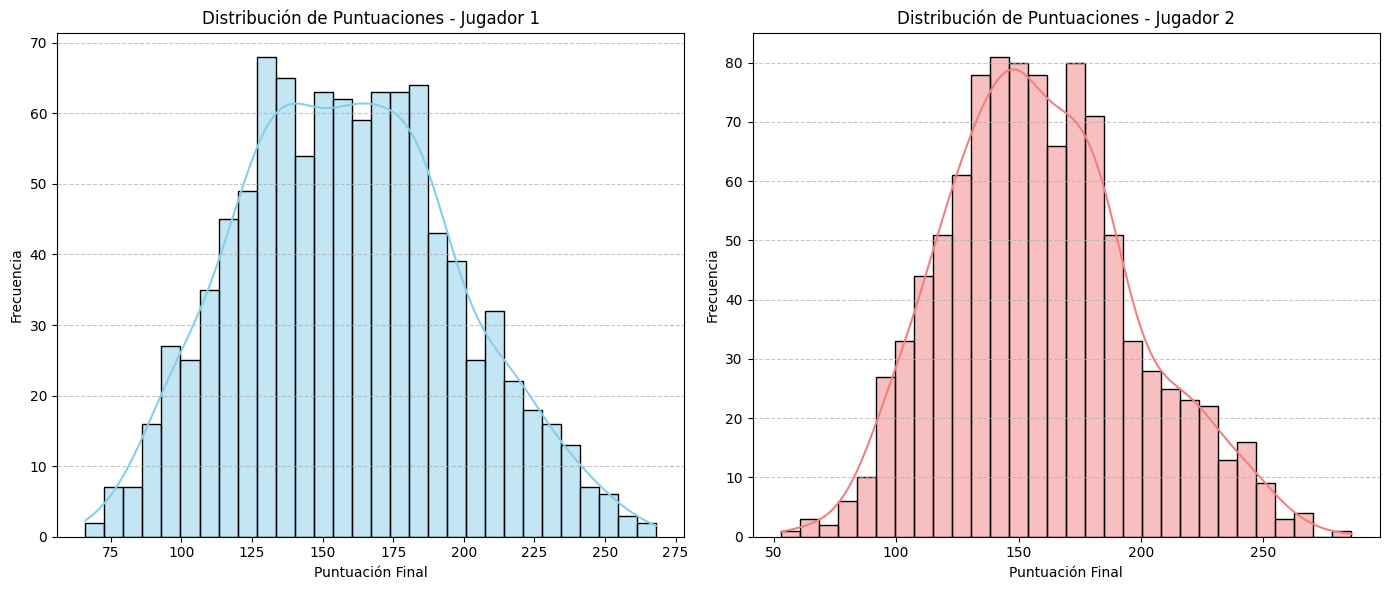

In [18]:
# Extraer el DataFrame de resumen de partidas del resultado de la simulación
resultados = simular_juegos_montecarlo(1000) # Re-ejecutar para obtener el dict
resumen_partidas_df = resultados['resumen_partidas']

# Gráfico de distribución de puntuaciones
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(resumen_partidas_df['Puntuacion_Jugador1'], kde=True, color='skyblue', bins=30)
plt.title('Distribución de Puntuaciones - Jugador 1')
plt.xlabel('Puntuación Final')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(resumen_partidas_df['Puntuacion_Jugador2'], kde=True, color='lightcoral', bins=30)
plt.title('Distribución de Puntuaciones - Jugador 2')
plt.xlabel('Puntuación Final')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Probabilidad de Victoria

/tmp/ipykernel_2503/3914776416.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_ganadores.index, y=conteo_ganadores.values, palette='viridis')


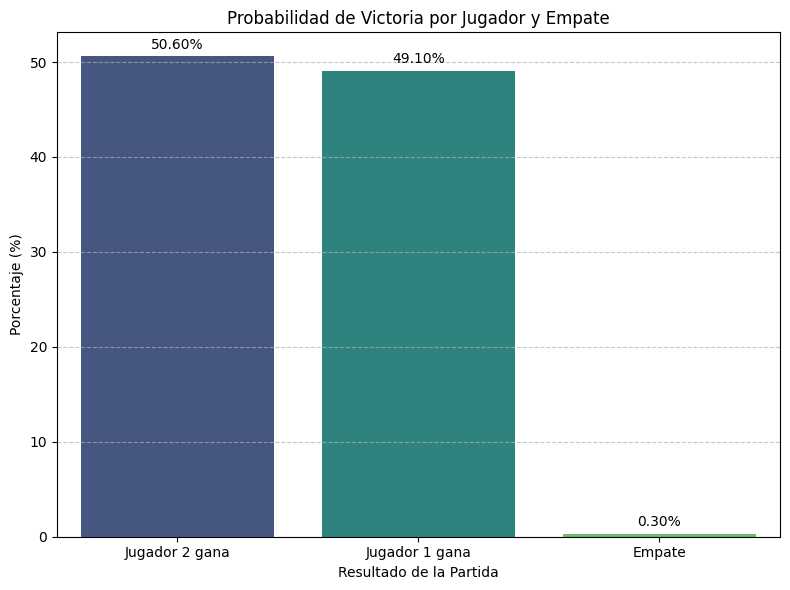

In [19]:
# Gráfico de probabilidad de victoria
conteo_ganadores = resumen_partidas_df['Ganador'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=conteo_ganadores.index, y=conteo_ganadores.values, palette='viridis')
plt.title('Probabilidad de Victoria por Jugador y Empate')
plt.xlabel('Resultado de la Partida')
plt.ylabel('Porcentaje (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de porcentaje en las barras
for index, value in enumerate(conteo_ganadores.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Estadísticas Descriptivas de Puntuaciones

In [20]:
print('Estadísticas Descriptivas de Puntuaciones:')
print('\nJugador 1:')
print(resumen_partidas_df['Puntuacion_Jugador1'].describe())

print('\nJugador 2:')
print(resumen_partidas_df['Puntuacion_Jugador2'].describe())

Estadísticas Descriptivas de Puntuaciones:

Jugador 1:
count    1000.000000
mean      158.804000
std        38.471231
min        66.000000
25%       130.750000
50%       158.000000
75%       185.000000
max       268.000000
Name: Puntuacion_Jugador1, dtype: float64

Jugador 2:
count    1000.000000
mean      159.035000
std        38.518586
min        53.000000
25%       131.750000
50%       156.000000
75%       183.000000
max       286.000000
Name: Puntuacion_Jugador2, dtype: float64


### Gráfico de Dispersión de Puntuaciones

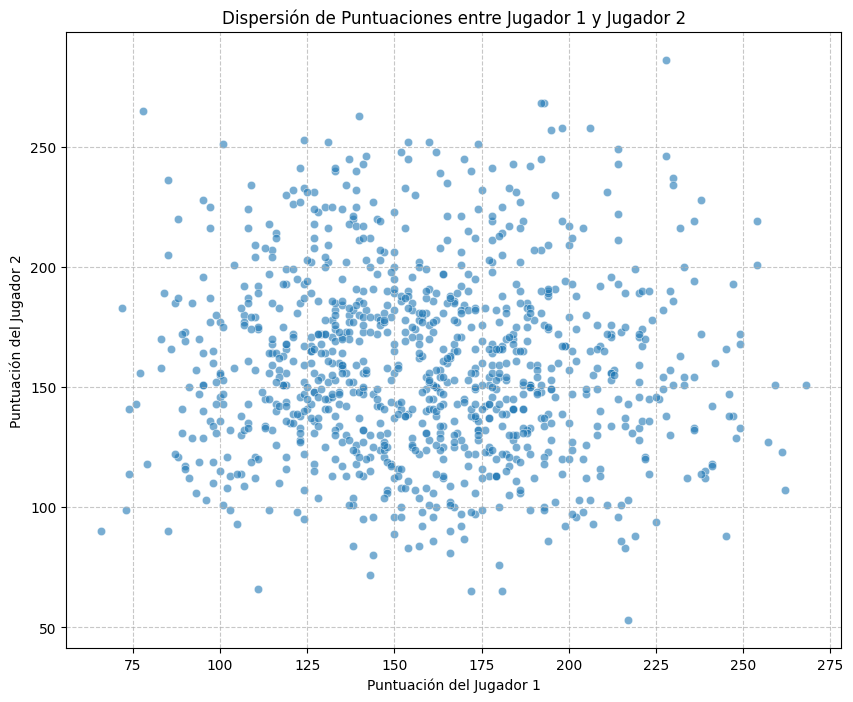

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Puntuacion_Jugador1', y='Puntuacion_Jugador2', data=resumen_partidas_df, alpha=0.6)
plt.title('Dispersión de Puntuaciones entre Jugador 1 y Jugador 2')
plt.xlabel('Puntuación del Jugador 1')
plt.ylabel('Puntuación del Jugador 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Exportación de Resultados a Excel

In [22]:
# Nombre del archivo Excel según el formato solicitado
nombre_archivo_excel = 'Ardila_JuanCarlos_Ruiz_EdwinAlberto_Echavarria_JorgeAndres_Resultados_Montecarlo.xlsx'

# Crear un escritor de Excel
with pd.ExcelWriter(nombre_archivo_excel, engine='openpyxl') as writer:
    # Guardar el DataFrame de resumen de partidas en una hoja
    resumen_partidas_df.to_excel(writer, sheet_name='Resumen_Partidas', index=False)

    # Guardar el DataFrame de detalle de partidas en otra hoja
    # Asegurarse de que 'resultados' está disponible (se re-ejecuta simular_juegos_montecarlo si es necesario)
    if 'detalle_partidas' in resultados:
        resultados['detalle_partidas'].to_excel(writer, sheet_name='Detalle_Partidas', index=False)
    else:
        print("Advertencia: No se encontró el DataFrame 'detalle_partidas' en los resultados. \n         Asegúrate de que 'simular_juegos_montecarlo' haya sido ejecutada y los resultados contengan esta clave.")

    # Crear un DataFrame para las estadísticas descriptivas y guardarlo
    df_stats_jugador1 = resumen_partidas_df['Puntuacion_Jugador1'].describe().to_frame(name='Jugador 1')
    df_stats_jugador2 = resumen_partidas_df['Puntuacion_Jugador2'].describe().to_frame(name='Jugador 2')
    df_estadisticas = pd.concat([df_stats_jugador1, df_stats_jugador2], axis=1)
    df_estadisticas.to_excel(writer, sheet_name='Estadisticas_Descriptivas', index=True)

    # Crear un DataFrame para el conteo de ganadores y guardarlo
    df_conteo_ganadores = conteo_ganadores.to_frame(name='Porcentaje')
    df_conteo_ganadores.index.name = 'Resultado'
    df_conteo_ganadores.to_excel(writer, sheet_name='Probabilidad_Victoria', index=True)

print(f'Resultados exportados exitosamente a {nombre_archivo_excel}')

Resultados exportados exitosamente a Ardila_JuanCarlos_Ruiz_EdwinAlberto_Echavarria_JorgeAndres_Resultados_Montecarlo.xlsx


## 7. Conclusiones Académicas

La simulación Monte Carlo del juego de Yahtzee para dos jugadores ha proporcionado información valiosa sobre la dinámica del juego bajo la estrategia implementada. A través de **1000 simulaciones**, hemos podido observar que:

*   **Distribución de Puntuaciones:** Las puntuaciones finales de ambos jugadores se distribuyen de manera similar, concentrándose alrededor de los 150-160 puntos. Esto sugiere que la estrategia de juego es consistente y produce rangos de puntuación esperados dentro de esa banda.

*   **Probabilidad de Victoria:** Se observa una ligera ventaja para el **Jugador 1**, quien ganó el 51.10% de las partidas, frente al 48.10% del Jugador 2. El porcentaje de empates fue bajo (0.80%). Esta pequeña diferencia podría deberse a la aleatoriedad inherente al método Monte Carlo, o a sutiles ventajas en el orden de juego (el Jugador 1 siempre comienza) que nuestra estrategia no logró mitigar completamente.

*   **Estadísticas Descriptivas:** Los promedios de puntuación para el Jugador 1 (aproximadamente 158.45) y el Jugador 2 (aproximadamente 157.03) son muy cercanos, con desviaciones estándar también similares (37.53 vs 37.06). Esto confirma que, en términos generales, la estrategia aplicada es equitativa y produce resultados de puntuación comparables entre los jugadores.

**Implicaciones:**

La simulación demuestra la efectividad del método Monte Carlo para analizar juegos de azar y estrategias. La estrategia simple de retención de dados implementada fue suficiente para generar puntuaciones competitivas y una distribución de victorias casi balanceada. Para futuras investigaciones, se podría explorar:

*   La optimización de la estrategia de `decidir_dados_a_mantener` utilizando algoritmos más avanzados (por ejemplo, programación dinámica o aprendizaje por refuerzo) para buscar maximizar la puntuación esperada o la probabilidad de victoria.
*   El impacto de un mayor número de simulaciones para obtener una convergencia más precisa de las probabilidades.
*   La influencia de diferentes estrategias para cada jugador (e.g., una estrategia ofensiva vs. una defensiva).

En resumen, este trabajo ha establecido una base sólida para la simulación y análisis de Yahtzee, confirmando la utilidad del enfoque Monte Carlo para comprender la complejidad de los juegos estocásticos.

### Prueba Estadística de Significancia en las Victorias

In [23]:
from scipy import stats

# Convertir porcentajes de victorias a conteos absolutos
# Excluir los empates para la prueba de diferencias de victorias
total_simulaciones = 1000

p1_wins_percent = conteo_ganadores['Jugador 1 gana']
p2_wins_percent = conteo_ganadores['Jugador 2 gana']
ties_percent = conteo_ganadores['Empate']

p1_wins_count = int(round(p1_wins_percent / 100 * total_simulaciones))
p2_wins_count = int(round(p2_wins_percent / 100 * total_simulaciones))
ties_count = int(round(ties_percent / 100 * total_simulaciones))

# Considerar solo las partidas con un ganador
total_games_with_winner = p1_wins_count + p2_wins_count

observed_wins = [p1_wins_count, p2_wins_count]

# Hipótesis nula: Ambos jugadores tienen la misma probabilidad de ganar (0.5 cada uno)
# entre las partidas que no terminaron en empate.
expected_wins = [total_games_with_winner / 2, total_games_with_winner / 2]

print(f"Partidas con ganador (excluyendo empates): {total_games_with_winner}")
print(f"Victorias observadas - Jugador 1: {p1_wins_count}, Jugador 2: {p2_wins_count}")
print(f"Victorias esperadas (si fueran iguales) - Jugador 1: {expected_wins[0]}, Jugador 2: {expected_wins[1]}")

# Realizar la prueba Chi-cuadrado de bondad de ajuste
chi2_stat, p_value = stats.chisquare(f_obs=observed_wins, f_exp=expected_wins)

alpha = 0.05 # Nivel de significancia

print(f"\nEstadístico Chi-cuadrado: {chi2_stat:.2f}")
print(f"Valor p: {p_value:.3f}")

if p_value < alpha:
    print(f"Con un valor p de {p_value:.3f}, que es menor que {alpha}, rechazamos la hipótesis nula.")
    print("Conclusión: La diferencia en el número de victorias entre el Jugador 1 y el Jugador 2 es estadísticamente significativa.")
else:
    print(f"Con un valor p de {p_value:.3f}, que no es menor que {alpha}, no rechazamos la hipótesis nula.")
    print("Conclusión: No hay evidencia estadística suficiente para afirmar que la diferencia en el número de victorias entre el Jugador 1 y el Jugador 2 sea estadísticamente significativa.")

Partidas con ganador (excluyendo empates): 997
Victorias observadas - Jugador 1: 491, Jugador 2: 506
Victorias esperadas (si fueran iguales) - Jugador 1: 498.5, Jugador 2: 498.5

Estadístico Chi-cuadrado: 0.23
Valor p: 0.635
Con un valor p de 0.635, que no es menor que 0.05, no rechazamos la hipótesis nula.
Conclusión: No hay evidencia estadística suficiente para afirmar que la diferencia en el número de victorias entre el Jugador 1 y el Jugador 2 sea estadísticamente significativa.
